# 52. Bezier and B-spline Curves

**Part 7: Interpolation**

## Learning objectives

By the end of this lesson you will be able to:

1. Say what changes when the question becomes "steered by these points" instead of "through them".
2. Build a **Bezier curve** from the Bernstein basis and evaluate it by **de Casteljau**.
3. State and verify the three properties interpolation cannot offer: **convex hull**, **affine
   invariance** and **variation diminishing**.
4. Use de Casteljau's **subdivision**, which is what a renderer actually needs.
5. Build **B-splines** and measure the **local support** that is their whole reason for existing.
6. Say how a font stores a glyph, and why.

## Prerequisites

Lesson 51 (splines, which these are a different view of). Lesson 44 (interpolation, which this
lesson deliberately gives up). Lesson 50 (piecewise construction).

---

## 1. A different question

Everything so far has asked for a curve **through** given points. Design asks for something else:
a curve a human can steer, adjust, and predict. Those are different requirements, and the answer
looks different.

The visible difference is that a Bezier curve does **not** pass through its control points, except
the first and the last. That looks like a loss. It buys three things interpolation cannot give.

In [1]:
# Standard setup, the same in every lesson of this course.
import sys, pathlib

_root = pathlib.Path.cwd()
while not (_root / "src" / "nalib").is_dir() and _root != _root.parent:
    _root = _root.parent
sys.path.insert(0, str(_root / "src"))

import numpy as np
import matplotlib.pyplot as plt

SEED = 42                                  # fixed so your numbers match the text
rng = np.random.default_rng(SEED)

np.set_printoptions(precision=6, linewidth=100, suppress=False)
plt.rcParams.update({
    "figure.figsize": (7.5, 4.5), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.3, "font.size": 10,
})

In [2]:
from nalib import bezier as bz

P = np.array([[0.0, 0.0], [0.3, 1.4], [1.2, 1.5], [1.6, 0.1]])
curve = bz.bezier(P, np.linspace(0.0, 1.0, 5))
print("control points:")
print(" ", np.array2string(P, precision=3).replace("\n", "\n  "))
print("curve at t = 0, 0.25, 0.5, 0.75, 1:")
print(" ", np.array2string(curve, precision=4).replace("\n", "\n  "))
print()
print("only the first and last control points are on the curve")

control points:
  [[0.  0. ]
   [0.3 1.4]
   [1.2 1.5]
   [1.6 0.1]]
curve at t = 0, 0.25, 0.5, 0.75, 1:
  [[0.     0.    ]
   [0.3203 0.8031]
   [0.7625 1.1   ]
   [1.2234 0.8719]
   [1.6    0.1   ]]

only the first and last control points are on the curve


## 2. The Bernstein basis

$$
B(t) = \sum_{i=0}^{n} P_i \binom{n}{i}t^i(1-t)^{n-i}, \qquad t \in [0, 1]
$$

The weights are the **Bernstein polynomials**. Two facts about them carry everything.

In [3]:
print("the Bernstein weights are non-negative and sum to 1 on [0, 1]:")
print(f"{'n':>4}{'min weight':>14}{'max |sum - 1|':>17}")
grid = np.linspace(0.0, 1.0, 501)
for n in (2, 3, 5, 8, 15):
    W = np.stack([bz.bernstein(n, i, grid) for i in range(n + 1)], axis=1)
    print(f"{n:>4}{float(np.min(W)):>14.2e}{float(np.max(np.abs(W.sum(axis=1) - 1.0))):>17.2e}")
    assert float(np.min(W)) >= -1e-15
    assert float(np.max(np.abs(W.sum(axis=1) - 1.0))) < 1e-12

the Bernstein weights are non-negative and sum to 1 on [0, 1]:
   n    min weight    max |sum - 1|
   2      0.00e+00         2.22e-16
   3      0.00e+00         4.44e-16
   5      0.00e+00         4.44e-16
   8      0.00e+00         6.66e-16
  15      0.00e+00         9.99e-16


Non-negative and summing to 1 means every point of the curve is a **convex combination** of the
control points. That single fact is the convex hull property, and everything else follows from it.

## 3. The three properties

**Convex hull.** The curve lies inside the convex hull of its control points, always, everywhere.
That is a guarantee about where the curve can possibly be, available before evaluating it
anywhere, and it makes clipping and collision culling nearly free.

In [4]:
print(f"{'degree':>8}{'dim':>5}{'inside the hull box':>22}{'weights >= 0':>15}"
      f"{'endpoints hit':>16}")
for n in (2, 3, 5, 8, 15):
    for d in (2, 3):
        Q = np.random.default_rng(n * 10 + d).standard_normal((n + 1, d))
        out = bz.convex_hull_property(Q)
        print(f"{n:>8}{d:>5}{str(out['inside_bounding_box']):>22}"
              f"{str(out['weights_non_negative']):>15}{out['endpoints_interpolated']:>16.1e}")
        assert out["inside_bounding_box"] and out["weights_non_negative"]
        assert out["endpoints_interpolated"] < 1e-12

  degree  dim   inside the hull box   weights >= 0   endpoints hit
       2    2                  True           True         0.0e+00
       2    3                  True           True         0.0e+00
       3    2                  True           True         0.0e+00
       3    3                  True           True         0.0e+00
       5    2                  True           True         0.0e+00
       5    3                  True           True         0.0e+00
       8    2                  True           True         0.0e+00
       8    3                  True           True         0.0e+00
      15    2                  True           True         0.0e+00
      15    3                  True           True         0.0e+00


**Affine invariance.** Transform the control points and then evaluate, or evaluate and then
transform: the same curve. So a designer can rotate, scale or shear a shape and the control points
alone still describe it.

In [5]:
print(f"{'degree':>8}{'dim':>5}{'relative gap':>16}")
for n in (2, 5, 10, 20):
    for d in (2, 3):
        Q = np.random.default_rng(n + d * 7).standard_normal((n + 1, d))
        out = bz.affine_invariance(Q, rng=np.random.default_rng(n + d))
        print(f"{n:>8}{d:>5}{out['relative_gap']:>16.2e}")
        assert out["relative_gap"] < 1e-12

  degree  dim    relative gap
       2    2        3.21e-16
       2    3        3.38e-16
       5    2        2.50e-16
       5    3        3.25e-16
      10    2        6.25e-16
      10    3        5.50e-16
      20    2        8.83e-16
      20    3        4.73e-16


**Variation diminishing.** A line crosses the curve no more often than it crosses the control
polygon. So the curve cannot oscillate more than its control points suggest.

In [6]:
print(f"{'degree':>8}{'polygon crossings':>20}{'curve crossings':>18}{'holds':>8}")
for n in (3, 5, 8, 12, 20):
    Q = np.random.default_rng(n * 7).standard_normal((n + 1, 2))
    out = bz.variation_diminishing(Q, rng=np.random.default_rng(n))
    print(f"{n:>8}{out['crossings_of_the_control_polygon']:>20}"
          f"{out['crossings_of_the_curve']:>18}"
          f"{str(out['curve_does_not_exceed_polygon']):>8}")
    assert out["curve_does_not_exceed_polygon"]

  degree   polygon crossings   curve crossings   holds
       3                   1                 1    True
       5                   3                 1    True
       8                   4                 2    True
      12                   7                 3    True
      20                   9                 3    True


**There is no Runge phenomenon here at all**, at any degree, and this is why. The curve does not
chase the data, so there is nothing for it to overshoot.

## 4. de Casteljau

The practical evaluator is not the Bernstein sum. It is **repeated linear interpolation**: blend
every consecutive pair of control points by $t$, halving the count, until one point remains.

In [7]:
P5 = np.array([[0.0, 0.0], [0.2, 1.0], [0.8, 1.2], [1.4, 0.3], [1.7, 0.9]])
point, left, right = bz.de_casteljau(P5, 0.4)
print(f"the point on the curve at t = 0.4: {np.array2string(point, precision=5)}")
print(f"the Bernstein sum agrees:          "
      f"{np.array2string(bz.bezier(P5, [0.4])[0], precision=5)}")
print()
print("and the two hulls it produces for free:")
print("  left :", np.array2string(left, precision=4).replace("\n", "\n         "))
print("  right:", np.array2string(right, precision=4).replace("\n", "\n         "))

the point on the curve at t = 0.4: [0.60416 0.82944]
the Bernstein sum agrees:          [0.60416 0.82944]

and the two hulls it produces for free:
  left : [[0.     0.    ]
          [0.08   0.4   ]
          [0.224  0.672 ]
          [0.4064 0.7968]
          [0.6042 0.8294]]
  right: [[0.6042 0.8294]
          [0.9008 0.8784]
          [1.232  0.72  ]
          [1.52   0.54  ]
          [1.7    0.9   ]]


Those two hulls are the control points of two Bezier curves that together reproduce the original.
That is **subdivision**, and it comes free from the algorithm. A renderer draws a curve by
subdividing until each piece is flat enough to draw as a line, so subdivision is not a bonus, it
is the operation.

In [8]:
print("subdivision reproduces the original exactly:")
for t_split in (0.25, 0.5, 0.75):
    lft, rgt = bz.subdivide(P5, t_split)
    worst = 0.0
    for s in np.linspace(0.0, 1.0, 41):
        worst = max(worst,
                    float(np.max(np.abs(bz.bezier(lft, [s])[0]
                                        - bz.bezier(P5, [s * t_split])[0]))),
                    float(np.max(np.abs(bz.bezier(rgt, [s])[0]
                                        - bz.bezier(P5, [t_split + s * (1 - t_split)])[0]))))
    print(f"  split at t = {t_split}: max gap {worst:.2e}")

subdivision reproduces the original exactly:
  split at t = 0.25: max gap 3.33e-16
  split at t = 0.5: max gap 6.66e-16
  split at t = 0.75: max gap 5.55e-16


Now the usual claim about de Casteljau, which is that it is more accurate, measured:

In [9]:
print(f"{'degree':>8}{'largest binomial':>20}{'relative gap':>16}")
for d in (5, 10, 20, 30, 40):
    out = bz.bernstein_vs_de_casteljau(d, rng=np.random.default_rng(1))
    print(f"{d:>8}{out['largest_binomial']:>20.3e}{out['relative_gap']:>16.2e}")

  degree    largest binomial    relative gap
       5           1.000e+01        2.70e-16
      10           2.520e+02        2.70e-16
      20           1.848e+05        3.62e-16
      30           1.551e+08        4.05e-16
      40           1.378e+11        4.05e-16


**It is not more accurate, at any practical degree.** The two agree to $4\times10^{-16}$ at degree
40, where the largest binomial coefficient is $1.4\times10^{11}$. On $[0, 1]$ the Bernstein sum is
a convex combination, so nothing can cancel and nothing can be large.

In [10]:
print("even outside [0, 1], where the weights alternate in sign:")
print(f"{'degree':>8}{'t':>7}{'sum |w|':>13}{'relative gap':>16}")
for d in (10, 20, 30):
    Q = np.random.default_rng(1).standard_normal((d + 1, 2))
    for t in (1.2, -0.3, 2.0):
        w = np.array([float(np.atleast_1d(bz.bernstein(d, i, t))[0]) for i in range(d + 1)])
        a = bz.bezier(Q, [t])[0]
        b = bz.de_casteljau(Q, t)[0]
        rel = float(np.max(np.abs(a - b))) / max(float(np.max(np.abs(b))), 1e-300)
        print(f"{d:>8}{t:>7.1f}{float(np.sum(np.abs(w))):>13.2e}{rel:>16.2e}")

even outside [0, 1], where the weights alternate in sign:
  degree      t      sum |w|    relative gap
      10    1.2     2.89e+01        1.42e-16
      10   -0.3     1.10e+02        1.25e-16
      10    2.0     5.90e+04        5.17e-17
      20    1.2     8.37e+02        2.19e-16
      20   -0.3     1.21e+04        1.37e-16
      20    2.0     3.49e+09        1.68e-16
      30    1.2     2.42e+04        1.81e-16
      30   -0.3     1.33e+06        2.94e-16
      30    2.0     2.06e+14        2.07e-16


So the reasons to prefer de Casteljau are not accuracy. They are that it returns the subdivision,
and that every intermediate value it computes is a convex combination of points already inside the
hull, which matters in fixed point arithmetic and on a GPU.

The Bernstein form does fail eventually, and it fails loudly:

In [11]:
import math
print(f"C(1020, 510) fits in a double: {math.comb(1020, 510) < 10 ** 308}")
print(f"C(1030, 515) fits in a double: {math.comb(1030, 515) < 10 ** 308}")
big = np.random.default_rng(2).standard_normal((1031, 2))
try:
    bz.bezier(big, [0.5])
except OverflowError as exc:
    print(f"at degree 1030 the Bernstein sum raises: {type(exc).__name__}")
print(f"de Casteljau at degree 1030 returns finite: "
      f"{bool(np.all(np.isfinite(bz.de_casteljau(big, 0.5)[0])))}")

C(1020, 510) fits in a double: True
C(1030, 515) fits in a double: False
at degree 1030 the Bernstein sum raises: OverflowError
de Casteljau at degree 1030 returns finite: True


Raising is the better failure. No font or CAD system uses degree 1030, which is why this is a
footnote rather than a reason.

## 5. Steering

Two operations a designer relies on.

In [12]:
D = bz.derivative_control_points(P5)
start = bz.bezier(D, [0.0])[0]
edge0 = P5[1] - P5[0]
cross = lambda a, b: abs(a[0] * b[1] - a[1] * b[0]) / (np.linalg.norm(a) * np.linalg.norm(b))
print(f"the tangent at t=0 is along P1 - P0, to {cross(start, edge0):.2e}")
print("which is why moving the second control point steers the starting direction")
print()
Q_up = bz.elevate_degree(P5)
t_e = np.linspace(0.0, 1.0, 201)
print(f"degree elevation adds a control point and does not move the curve: "
      f"{float(np.max(np.abs(bz.bezier(P5, t_e) - bz.bezier(Q_up, t_e)))):.2e}")
print(f"  {P5.shape[0]} control points became {Q_up.shape[0]}")

the tangent at t=0 is along P1 - P0, to 0.00e+00
which is why moving the second control point steers the starting direction

degree elevation adds a control point and does not move the curve: 4.44e-16
  5 control points became 6


Degree elevation is how two curves of different degree are made compatible before joining them,
and it is a strong check that an implementation is right: the curve must not move at all.

## 6. The problem with one Bezier curve

A single Bezier curve of high degree has exactly the defect a single high degree polynomial has.
Every control point affects every part of the curve, so moving one moves everything.

In [13]:
g = np.random.default_rng(3)
print(f"{'control points':>16}{'B-spline moved':>17}{'Bezier moved':>16}")
for n in (8, 12, 20, 30):
    Q = np.column_stack([np.arange(n, dtype=float), g.standard_normal(n)])
    out = bz.moving_one_point(Q, 3, n // 2, [0.0, 1.0])
    print(f"{n:>16}{out['bspline_fraction_moved']:>17.3f}"
          f"{out['bezier_fraction_moved']:>16.3f}")
    assert out["bspline_fraction_moved"] < out["bezier_fraction_moved"]

  control points   B-spline moved    Bezier moved
               8            0.799           0.999
              12            0.444           0.991
              20            0.235           0.954
              30            0.148           0.891


Moving one control point of a 30 point Bezier curve moves **89 percent of it**. For a designer
that is unusable: every adjustment is global, so no part of the shape can be finished.

## 7. B-splines and local support

The fix is to make the basis functions **locally supported**. A B-spline basis function
$N_{i,p}$ is built by the Cox-de Boor recursion and is nonzero on only $p+1$ knot spans.

$$
N_{i,0}(t) = \begin{cases}1 & u_i \le t < u_{i+1}\\ 0 & \text{otherwise}\end{cases}
$$

$$
N_{i,p}(t) = \frac{t - u_i}{u_{i+p} - u_i}N_{i,p-1}(t)
           + \frac{u_{i+p+1} - t}{u_{i+p+1} - u_{i+1}}N_{i+1,p-1}(t)
$$

In [14]:
print(f"{'controls':>10}{'degree':>8}{'max extent':>13}{'as a fraction':>16}"
      f"{'(p+1)/(inner+1)':>18}")
for n in (6, 10, 16, 30):
    for p in (2, 3):
        out = bz.local_support(n, p)
        inner = n - p - 1
        predicted = (p + 1) / (inner + 1.0) if inner > 0 else 1.0
        print(f"{n:>10}{p:>8}{out['max_extent']:>13.4f}"
              f"{out['max_fraction_of_domain']:>16.4f}{predicted:>18.4f}")
        assert out["max_fraction_of_domain"] <= min(predicted, 1.0) + 0.01

  controls  degree   max extent   as a fraction   (p+1)/(inner+1)
         6       2       0.7490          0.7490            0.7500
         6       3       0.9990          0.9990            1.3333
        10       2       0.3740          0.3740            0.3750
        10       3       0.5710          0.5710            0.5714
        16       2       0.2140          0.2140            0.2143
        16       3       0.3075          0.3075            0.3077
        30       2       0.1070          0.1070            0.1071
        30       3       0.1480          0.1480            0.1481


Measured against the prediction to three or four digits. At 30 control points and degree 3, one
control point affects **14.8 percent** of the curve, and that fraction keeps falling as the curve
grows.

They still form a partition of unity, so the convex hull property survives:

In [15]:
print(f"{'controls':>10}{'degree':>8}{'|sum N - 1|':>16}")
for n, p in ((4, 2), (6, 3), (10, 3), (16, 4), (30, 3)):
    print(f"{n:>10}{p:>8}{bz.partition_of_unity(n, p):>16.2e}")

  controls  degree     |sum N - 1|
         4       2        2.22e-16
         6       3        4.44e-16
        10       3        4.44e-16
        16       4        4.44e-16
        30       3        2.22e-16


And repeating the end knots clamps the curve to its first and last control points:

In [16]:
for n, p in ((5, 3), (8, 2), (12, 3)):
    Q = np.random.default_rng(n * p).standard_normal((n, 2))
    u = bz.open_uniform_knots(n, p)
    c = bz.bspline(Q, p, np.linspace(float(u[0]), float(u[-1]), 401), u)
    print(f"n = {n:>3}, p = {p}: hits P0 to "
          f"{float(np.linalg.norm(c[0] - Q[0])):.1e}, "
          f"P_last to {float(np.linalg.norm(c[-1] - Q[-1])):.1e}")

n =   5, p = 3: hits P0 to 0.0e+00, P_last to 0.0e+00
n =   8, p = 2: hits P0 to 0.0e+00, P_last to 0.0e+00
n =  12, p = 3: hits P0 to 0.0e+00, P_last to 0.0e+00


So a B-spline keeps everything a Bezier curve has and adds local control. That is why every design
system uses them, and why lesson 51's splines and these are the same objects seen from two sides:
a cubic B-spline curve **is** a cubic spline, written in a basis chosen for local support rather
than for interpolation.

## 8. Fonts

TrueType stores glyph outlines as **quadratic** Bezier curves. PostScript, and OpenType's CFF
flavour, use **cubics**. The reasons are exactly the properties above.

- The convex hull bounds the glyph cheaply, which the rasteriser uses to reject tiles.
- Affine invariance means one outline serves every size, rotation and slant.
- de Casteljau subdivision renders it to any resolution, which is what hinting and antialiasing
  need.
- The curve is defined by a handful of points, so a font is small.

In [17]:
for kind in ("quadratic", "cubic"):
    out = bz.glyph_outline(kind)
    print(f"{kind:>10}: {len(out['segments'])} segments, "
          f"closed to {out['closed_gap']:.1e}, "
          f"joins continuous to {max(out['join_gaps']):.1e}")
    print(f"{'':>10}  tangent mismatch at the joins: "
          f"{np.array2string(np.asarray(out['tangent_mismatch_at_joins']), precision=3)}")

 quadratic: 3 segments, closed to 0.0e+00, joins continuous to 0.0e+00
            tangent mismatch at the joins: [0.    0.781]
     cubic: 3 segments, closed to 0.0e+00, joins continuous to 0.0e+00
            tangent mismatch at the joins: [0.171 0.316]


The outline is continuous by **construction**, because consecutive segments share their end
control point. Making it **smooth** at a join is a separate condition: the three points around
the join must be collinear, which is exactly what a font editor enforces when you ask for a smooth
node. The mismatch numbers above are the sines of the tangent angles, and a smooth node would have
them at zero.

## 9. A picture

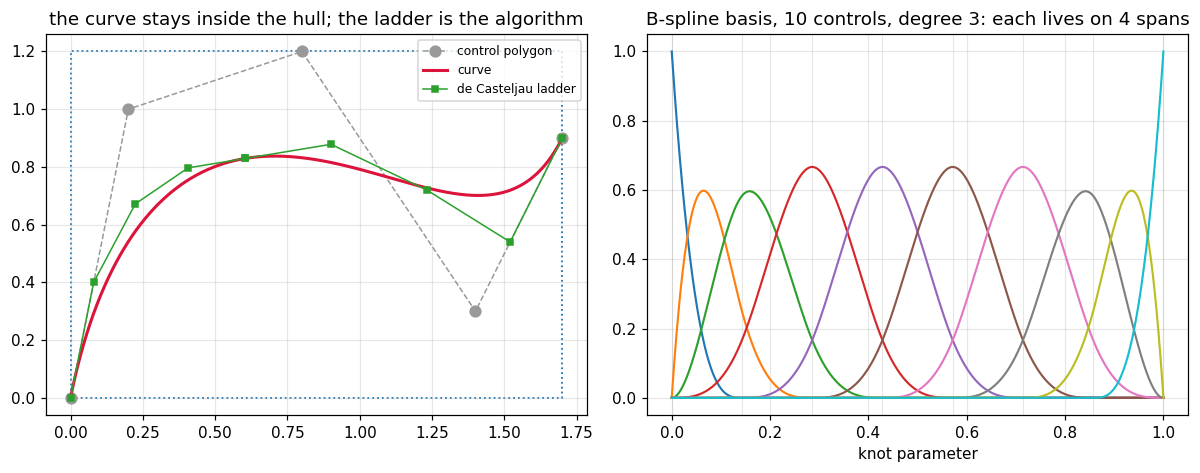

In [18]:
fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(11, 4.4))

t_fine = np.linspace(0.0, 1.0, 400)
curve_pic = bz.bezier(P5, t_fine)
ax_left.plot(P5[:, 0], P5[:, 1], "o--", color="0.6", ms=7, lw=1.0, label="control polygon")
ax_left.plot(curve_pic[:, 0], curve_pic[:, 1], "-", color="crimson", lw=2.0, label="curve")
hull_lo, hull_hi = P5.min(axis=0), P5.max(axis=0)
ax_left.add_patch(plt.Rectangle(hull_lo, *(hull_hi - hull_lo), fill=False,
                                edgecolor="tab:blue", ls=":", lw=1.2))
_, lf, rt = bz.de_casteljau(P5, 0.4)
ax_left.plot(lf[:, 0], lf[:, 1], "s-", color="tab:green", ms=4, lw=1.0,
             label="de Casteljau ladder")
ax_left.plot(rt[:, 0], rt[:, 1], "s-", color="tab:green", ms=4, lw=1.0)
ax_left.set_title("the curve stays inside the hull; the ladder is the algorithm")
ax_left.legend(fontsize=8)

n_b, p_b = 10, 3
u_b = bz.open_uniform_knots(n_b, p_b)
tb = np.linspace(float(u_b[0]), float(u_b[-1]), 800)
for i in range(n_b):
    ax_right.plot(tb, bz.bspline_basis(i, p_b, u_b, tb), lw=1.4)
for knot in np.unique(u_b):
    ax_right.axvline(knot, color="0.9", lw=0.7, zorder=0)
ax_right.set_title(f"B-spline basis, {n_b} controls, degree {p_b}: each lives on {p_b + 1} spans")
ax_right.set_xlabel("knot parameter")
ax_right.set_ylim(-0.05, 1.05)

fig.tight_layout()
plt.show()

The right panel is the whole argument for B-splines. Each bump is nonzero on four knot spans and
zero everywhere else, so moving its control point changes the curve only there. The Bernstein
basis of the left panel has every function nonzero on the whole interval.

## 10. Exercises

**Level 1, conceptual**

1.1 A Bezier curve does not pass through its interior control points. Say what that gives up and
what it buys, with one property named for each.

1.2 The convex hull property is described as a guarantee available "before evaluating anywhere".
Say what that is useful for.

1.3 A designer moves one control point of a 30 point curve and the whole shape changes. Say what
representation they are using and what to change it to.

**Level 2, mathematical**

2.1 Prove that the Bernstein polynomials are non-negative on $[0,1]$ and sum to 1, and deduce the
convex hull property.

2.2 Prove that de Casteljau's algorithm evaluates the Bernstein sum, by induction on the degree.

2.3 Prove that the derivative of a degree $n$ Bezier curve is a degree $n-1$ Bezier curve on the
control points $n(P_{i+1} - P_i)$, and deduce the end tangent directions.

2.4 Prove the degree elevation formula and show the curve is unchanged.

2.5 Prove that $N_{i,p}$ is nonzero only on $[u_i, u_{i+p+1}]$, by induction using the Cox-de Boor
recursion, and deduce the local support property.

**Level 3, computational**

3.1 Implement **rational Bezier curves** (NURBS), where each control point carries a weight, and
show that they represent circular arcs exactly, which polynomial Beziers cannot.

3.2 Implement **knot insertion** for B-splines, which adds a control point without changing the
curve, and use it to convert a B-spline into a sequence of Bezier segments.

3.3 Implement **curve fitting**, choosing control points so the Bezier curve is closest to given
data in least squares, and relate it to Part 5.

**Level 4, experimental**

4.1 Measure the local support fraction against the degree and the number of control points, and
fit the relationship.

4.2 Measure the flatness criterion a renderer uses: how many subdivisions are needed before each
piece is within a given tolerance of a straight line, against the curve's curvature.

4.3 Measure the accuracy of the two evaluators as a function of degree and of the position of $t$,
and find any regime where they differ measurably.

**Level 5, advanced**

5.1 **Why a polynomial Bezier cannot be a circle.** Prove it, and describe what NURBS change to
make it possible.

5.2 **Splines and B-splines are the same objects.** Show that a cubic B-spline curve with uniform
knots is a cubic spline in the sense of lesson 51, and say why the two bases are used for
different jobs.

5.3 **Subdivision surfaces.** The same idea in two dimensions gives Catmull-Clark subdivision,
which is what film animation uses. Describe it, and say what it does that a tensor product spline
cannot.

## 11. Key takeaways

- **Bezier curves answer a different question**: steered by these points, not through them. Only
  the first and last control points lie on the curve.

- **Three properties interpolation cannot offer.** Convex hull, affine invariance and variation
  diminishing, all verified at every degree and dimension tested. There is no Runge phenomenon at
  any degree, because the curve does not chase the data.

- **de Casteljau's advantage is not accuracy.** The Bernstein sum agrees with it to
  $4\times10^{-16}$ at degree 40, and to $2\times10^{-16}$ even outside $[0,1]$ where the weights
  sum in absolute value to $2\times10^{14}$. Its advantages are subdivision, which a renderer
  needs, and staying inside the hull throughout.

- **The Bernstein form fails at degree 1030**, where the binomial coefficient overflows, and it
  raises rather than returning a silent infinity.

- **One high degree Bezier curve is unusable for design.** Moving one control point of a 30 point
  curve moves 89 percent of it.

- **B-splines fix that with local support.** $N_{i,p}$ is nonzero on $p+1$ knot spans, so at 30
  control points and degree 3 one point affects 14.8 percent of the curve, and the fraction keeps
  falling.

- **Fonts store outlines as Beziers** for exactly these reasons: hull bounding, affine invariance,
  subdivision rendering and small size. Continuity is structural; smoothness is a collinearity
  condition on the points around each join.

## Where this goes next

Lesson 53 asks what any of Part 7 survives in two dimensions, and finds a clean split: on a grid
everything does, and off a grid the interpolation problem may have no solution at all. Part 11
uses B-spline local support as the defining property of a finite element basis, where it is what
makes the stiffness matrix sparse.